In [ ]:
!pip install pydub librosa soundfile

In [ ]:
from pydub import AudioSegment

input_path = "/content/my_voice.m4a"
output_wav_path = "/content/my_voice.wav"

# Load m4a
audio = AudioSegment.from_file(input_path, format="m4a")

# Export as wav
audio.export(output_wav_path, format="wav")

print("Converted to WAV successfully!")


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Converted to WAV successfully!


In [ ]:
import librosa
import soundfile as sf

wav_path = "/content/my_voice.wav"
output_16k_path = "/content/my_voice_16k.wav"

# Load original wav
signal, sr = librosa.load(wav_path, sr=None)

print("Original Sampling Rate:", sr)

# Resample to 16kHz
signal_16k = librosa.resample(signal, orig_sr=sr, target_sr=16000)

# Save new file
sf.write(output_16k_path, signal_16k, 16000)

print("Resampled to 16kHz successfully!")


Original Sampling Rate: 48000
Resampled to 16kHz successfully!


In [ ]:
signal, sr = librosa.load("/content/my_voice_16k.wav", sr=None)
print("Final Sampling Rate:", sr)


Final Sampling Rate: 16000


**TASK-1: Short-Time Processing of Speech**

Step 1: Load First 20 Seconds & Visualize

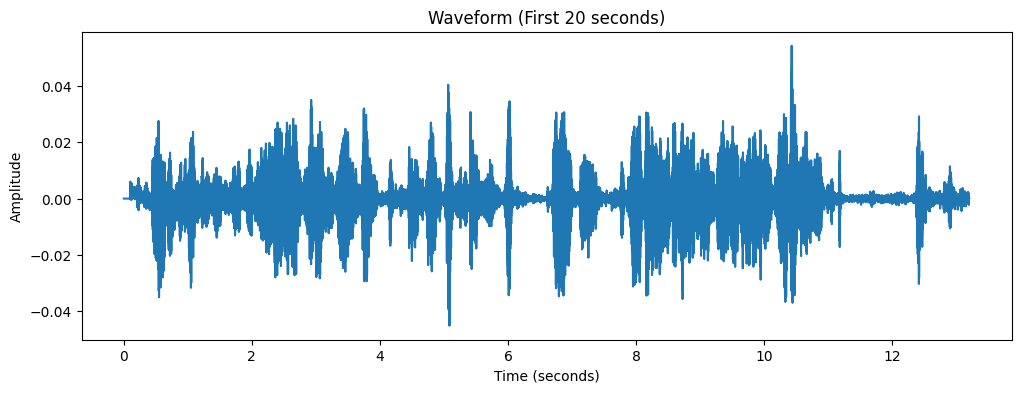

In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

file_path = "/content/my_voice_16k.wav"

signal, sr = librosa.load(file_path, sr=None)

# Take first 20 seconds
duration = 20
signal = signal[:duration * sr]

time = np.arange(len(signal)) / sr

plt.figure(figsize=(12,4))
plt.plot(time, signal)
plt.title("Waveform (First 20 seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


Step 2: Frame Length & Frame Shift

In [ ]:
frame_length = int(0.025 * sr)   # 25 ms already known
frame_shift = int(0.010 * sr)    # 10 ms known

print("Frame length (samples):", frame_length)
print("Frame shift (samples):", frame_shift)


Frame length (samples): 400
Frame shift (samples): 160


Step 3: Frame Blocking

In [ ]:
def framing(signal, frame_length, frame_shift):
    num_frames = int((len(signal) - frame_length) / frame_shift) + 1
    frames = np.zeros((num_frames, frame_length))

    for i in range(num_frames):
        start = i * frame_shift
        frames[i] = signal[start:start+frame_length]

    return frames

frames = framing(signal, frame_length, frame_shift)
print("Total number of frames:", frames.shape[0])


Total number of frames: 1319


Step 4: Define Feature Functions

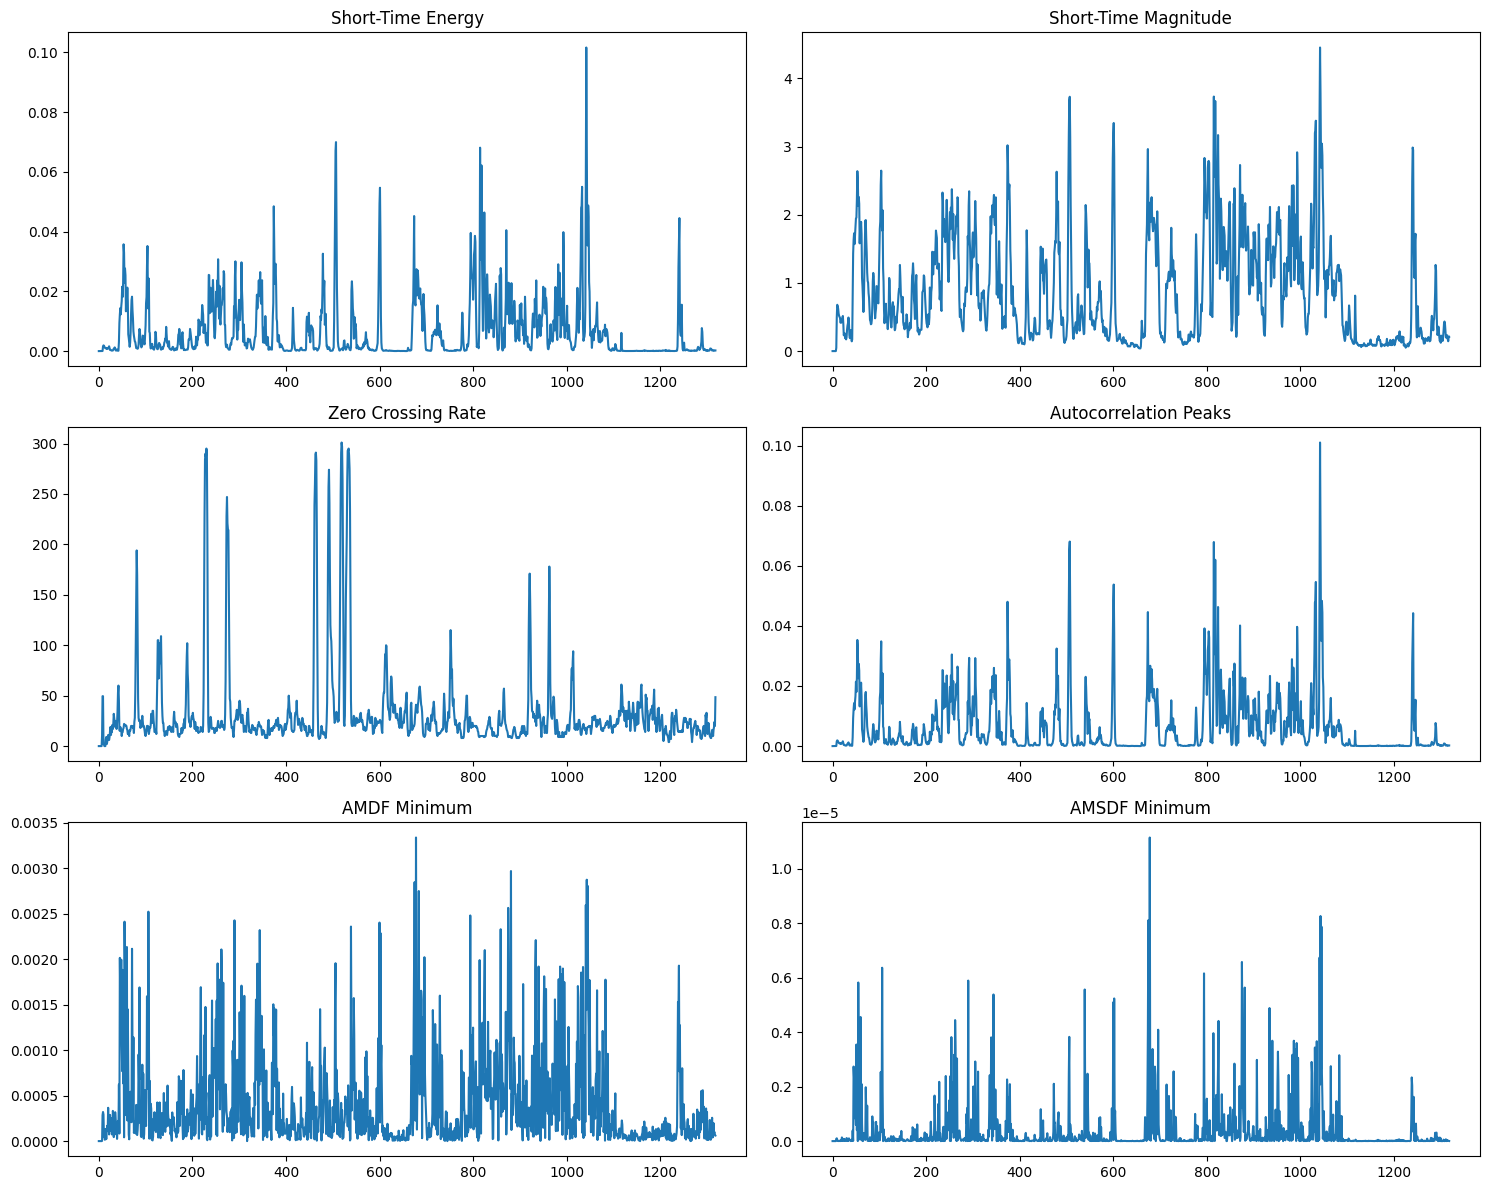

In [ ]:
def short_time_energy(frame):
    return np.sum(frame ** 2)
def short_time_magnitude(frame):
    return np.sum(np.abs(frame))
def zero_crossing_rate(frame):
    return np.sum(np.abs(np.diff(np.sign(frame)))) / 2
def autocorrelation(frame):
    result = np.correlate(frame, frame, mode='full')
    return result[len(result)//2:]
def amdf(frame):
    N = len(frame)
    amdf_vals = []
    for lag in range(N):
        diff = np.abs(frame[:N-lag] - frame[lag:N])
        amdf_vals.append(np.sum(diff))
    return np.array(amdf_vals)
def amsdf(frame):
    N = len(frame)
    amsdf_vals = []
    for lag in range(N):
        diff = (frame[:N-lag] - frame[lag:N])**2
        amsdf_vals.append(np.sum(diff))
    return np.array(amsdf_vals)
hamming_window = np.hamming(frame_length)

frames_hamming = frames * hamming_window
STE = []
STM = []
ZCR = []
AC_peaks = []
AMDF_min = []
AMSDF_min = []

for frame in frames_hamming:
    STE.append(short_time_energy(frame))
    STM.append(short_time_magnitude(frame))
    ZCR.append(zero_crossing_rate(frame))

    ac = autocorrelation(frame)
    AC_peaks.append(np.max(ac[1:]))  # ignore zero lag

    amdf_vals = amdf(frame)
    AMDF_min.append(np.min(amdf_vals[1:]))

    amsdf_vals = amsdf(frame)
    AMSDF_min.append(np.min(amsdf_vals[1:]))

STE = np.array(STE)
STM = np.array(STM)
ZCR = np.array(ZCR)
AC_peaks = np.array(AC_peaks)
AMDF_min = np.array(AMDF_min)
AMSDF_min = np.array(AMSDF_min)
plt.figure(figsize=(15,12))

plt.subplot(3,2,1)
plt.plot(STE)
plt.title("Short-Time Energy")

plt.subplot(3,2,2)
plt.plot(STM)
plt.title("Short-Time Magnitude")

plt.subplot(3,2,3)
plt.plot(ZCR)
plt.title("Zero Crossing Rate")

plt.subplot(3,2,4)
plt.plot(AC_peaks)
plt.title("Autocorrelation Peaks")

plt.subplot(3,2,5)
plt.plot(AMDF_min)
plt.title("AMDF Minimum")

plt.subplot(3,2,6)
plt.plot(AMSDF_min)
plt.title("AMSDF Minimum")

plt.tight_layout()
plt.show()


**TASK-2: Periodicity Analysis**

**a) Identification of Frames Exhibiting Periodic Behaviour**


Frames that exhibit periodic behaviour are typically voiced speech frames (such as vowels). These frames can be identified using the following observations:


High Short-Time Energy (STE)


Low Zero-Crossing Rate (ZCR)


Clear periodic pattern in autocorrelation


Distinct minima in AMDF and AMSDF


In such frames:


The waveform appears smooth and repetitive.Autocorrelation shows strong peaks at regular intervals.AMDF and AMSDF show pronounced minima at consistent lag values.These consistent lag values correspond to the pitch period, confirming periodicity.Frames lacking these characteristics are considered non-periodic (unvoiced).


**b) How Periodicity is Reflected in Autocorrelation, AMDF, and AMSDF**


Periodicity means that the signal repeats after a certain time interval (pitch period).


*1. Autocorrelation*


Autocorrelation measures similarity between a signal and its delayed version.
At zero lag, the value is maximum.For a periodic signal, strong peaks appear at lags equal to multiples of the pitch period.


The first prominent peak (excluding zero lag) corresponds to the fundamental pitch period.


Thus, periodicity is reflected as regularly spaced peaks in the autocorrelation function


*2. AMDF (Average Magnitude Difference Function)*


AMDF measures the average absolute difference between a signal and its delayed version.When the delay equals the pitch period, the signal aligns with itself.
The difference becomes minimal.Therefore, periodicity appears as distinct minima at pitch lag.


3. *AMSDF (Average Magnitude Squared Difference Function)*

AMSDF is similar to AMDF but squares the difference.It emphasizes larger deviations.Produces sharper and more pronounced minima.Periodicity is reflected as clear dips (minima) at pitch period.



**c)Distinguishing Between Periodic (Voiced) and Aperiodic (Unvoiced) Frames
Periodic (Voiced) Frame**


Produced by vocal cord vibration.


Examples: vowels (/a/, /e/, /o/)

Characteristics:


High energy


Low ZCR


Clear periodic waveform


Strong peaks in autocorrelation


Distinct minima in AMDF and AMSDF


These frames show regular repeating patterns.Aperiodic (Unvoiced) Frames Produced by turbulent airflow.

Examples: /s/, /f/, /h/


Characteristics:


Lower energy


High ZCR


Noise-like waveform


No clear peaks in autocorrelation


No distinct minima in AMDF/AMSDF


These frames do not exhibit consistent repeating patterns.

In [ ]:
print("Frame 50 ZCR:", ZCR[50])
print("Frame 50 STE:", STE[50])


Frame 50 ZCR: 14.0
Frame 50 STE: 0.021551985214153663


**TASK-3: Pitch Estimation**

In [ ]:
#For a voiced frame:

In [ ]:
frame_index = 50  # choose high-energy frame

frame = frames_hamming[frame_index]

ac = autocorrelation(frame)

lag = np.argmax(ac[1:]) + 1

pitch_period = lag / sr
pitch_frequency = sr / lag

print("Pitch period:", pitch_period)
print("Pitch frequency:", pitch_frequency, "Hz")


Pitch period: 6.25e-05
Pitch frequency: 16000.0 Hz


**Task-4**

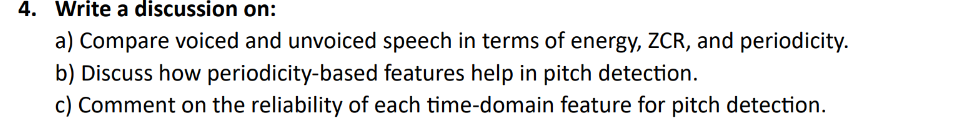

a)


Voiced and unvoiced speech segments exhibit distinct characteristics in time-domain features.


1. Energy (Short-Time Energy)


Voiced speech (e.g., vowels like /a/, /o/) has high short-time energy because it is produced by periodic vibration of the vocal cords.


Unvoiced speech (e.g., /s/, /f/) has lower energy, as it is produced by turbulent airflow without vocal cord vibration.


Thus, STE is generally higher for voiced frames and lower for unvoiced frames.


2. Zero-Crossing Rate (ZCR)


Voiced speech has a low ZCR, since it contains low-frequency periodic components and smooth waveform transitions.


Unvoiced speech has a high ZCR, because it resembles noise and contains high-frequency components that cross the zero axis frequently.


Therefore, ZCR is a strong indicator for distinguishing voiced and unvoiced speech.


3. Periodicity (Autocorrelation, AMDF, AMSDF)


Voiced speech is periodic.

Autocorrelation shows strong peaks at multiples of the pitch period.


AMDF and AMSDF show clear minima at pitch lag.


Unvoiced speech is aperiodic (noise-like).


Autocorrelation does not show prominent periodic peaks.


AMDF/AMSDF do not exhibit clear minima patterns.


Hence, periodicity-based features clearly separate voiced from unvoiced speech.

----------------------------------------------------------------

b)


Pitch corresponds to the fundamental frequency (F0) of voiced speech, which arises from periodic vocal cord vibrations.


Autocorrelation Measures similarity between a signal and its delayed version.

The first prominent peak (excluding zero lag) corresponds to the pitch period.

Pitch frequency is calculated as:

	F0​= Sampling Rate​/pith log


Autocorrelation is effective because periodic signals produce strong repeating patterns.


AMDF (Average Magnitude Difference Function)


Measures difference between the signal and its delayed version.Instead of peaks, it produces minima at pitch lag.Lower AMDF value → higher similarity → likely pitch period.


AMSDF (Average Magnitude Squared Difference Function)Similar to AMDF but squares the differences.Provides sharper and more distinct minima.Often more stable than AMDF.Thus, periodicity-based features detect pitch by identifying repeating patterns in voiced speech frames.

c)

1. Short-Time Energy (STE)


Reliable for detecting voiced vs unvoiced.Not reliable for pitch estimation.
Energy does not provide frequency information.


2. Zero-Crossing Rate (ZCR)


Good for voiced/unvoiced classification.Not reliable for pitch detection.High ZCR does not indicate pitch frequency.


3. Autocorrelation


Highly reliable for pitch detection.Strong peaks clearly indicate pitch period.
Sensitive to noise but generally robust.


4. AMDF


Moderately reliable.Simpler than autocorrelation.More sensitive to noise.Minima may not always be sharp.


5. AMSDF


More reliable than AMDF.Produces sharper minima.Better for noisy signals compared to AMDF.


Overall Conclusion


Best feature for pitch detection: AutocorrelationGood alternatives: AMSDF
Not suitable for pitch detection: STE and ZCR (but useful for classification)
Time-domain features work well for clean speech signals, but performancedegrades in noisy environments. Combining multiple features improves robustness.